# Implementing a Neural Network
In this exercise we will develop a neural network with fully-connected layers to perform classification, and test it out on the CIFAR-10 dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/2025_SE_AI_Expert/solutions

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/2025_SE_AI_Expert/solutions


In [2]:
import os

# Check if 'datasets/cifar-10-batches-py' exists
if not os.path.exists('datasets/cifar-10-batches-py'):
    # Make sure the datasets directory exists
    os.makedirs('datasets', exist_ok=True)

    # Download the CIFAR-10 dataset into the datasets folder
    !wget -P datasets http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

    # Extract the contents inside the datasets folder
    !tar -xzvf datasets/cifar-10-python.tar.gz -C datasets

    # Remove the downloaded tar.gz file
    !rm datasets/cifar-10-python.tar.gz
else:
    print("CIFAR-10 dataset already exists. Skipping download.")

CIFAR-10 dataset already exists. Skipping download.


In [3]:
# A bit of setup

import numpy as np
import matplotlib.pyplot as plt

from nn_classification_utils.classifiers.neural_net import TwoLayerNet

from __future__ import print_function

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

We will use the class `TwoLayerNet` in the file `nn_classification_utils/classifiers/neural_net.py` to represent instances of our network. The network parameters are stored in the instance variable `self.params` where keys are string parameter names and values are numpy arrays. Below, we initialize toy data and a toy model that we will use to develop your implementation.

In [4]:
# Create a small net and some toy data to check your implementations.
# Note that we set the random seed for repeatable experiments.

input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, weight_scale=1e-1, reg=0.05)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

model = init_toy_model()
X, y = init_toy_data()

# Forward pass: compute scores
Open the file `nn_classification_utils/classifiers/neural_net.py` and look at the method `TwoLayerNet.loss`. This function is very similar to the loss functions you have written for the SVM and Softmax exercises: It takes the data and weights and computes the class scores, the loss, and the gradients on the parameters.

Implement the first part of the forward pass which uses the weights and biases to compute the scores for all inputs.

In [5]:
scores = model.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()

# The difference should be very small. We get < 1e-7
print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08


# Forward pass: compute loss
In the same function, implement the second part that computes the data and regularizaion loss.

In [6]:
loss, _ = model.loss(X, y)
correct_loss = 1.30378789133

# should be very small, we get < 1e-12
print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Backward pass
Implement the rest of the function. This will compute the gradient of the loss with respect to the variables `W1`, `b1`, `W2`, and `b2`. Now that you (hopefully!) have a correctly implemented forward pass, you can debug your backward pass using a numeric gradient check:

In [7]:
from nn_classification_utils.gradient_check import eval_numerical_gradient

# Use numeric gradient checking to check your implementation of the backward pass.
# If your implementation is correct, the difference between the numeric and
# analytic gradients should be less than 1e-8 for each of W1, W2, b1, and b2.

loss, grads = model.loss(X, y)

# these should all be less than 1e-8 or so
for param_name in grads:
    f = lambda W: model.loss(X, y)[0]
    param_grad_num = eval_numerical_gradient(f, model.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

b2 max relative error: 4.447646e-11
W2 max relative error: 3.440708e-09
b1 max relative error: 2.738421e-09
W1 max relative error: 3.561318e-09


# Two-layer network
In the previous assignment you implemented a two-layer neural network in a single monolithic class. Now that you have implemented modular versions of the necessary layers, you will reimplement the two layer network using these modular implementations.

Open the file `nn_classifciation_utils/classifiers/neural_net.py` and complete the implementation of the `TwoLayerNet` class. This class will serve as a model for the other networks you will implement in this assignment, so read through it to make sure you understand the API. You can run the cell below to test your implementation.

# Solver
In the previous assignment, the logic for training models was coupled to the models themselves. Following a more modular design, for this assignment we have split the logic for training models into a separate class.

Open the file `nn_classification_utils/solver.py` and read through it to familiarize yourself with the API. After doing so, use a `Solver` instance to train a `TwoLayerNet`.

Once you have implemented the method, run the code below to train a two-layer network on toy data. You should achieve a training loss less than 0.2.

Final training loss:  0.013071470008909052


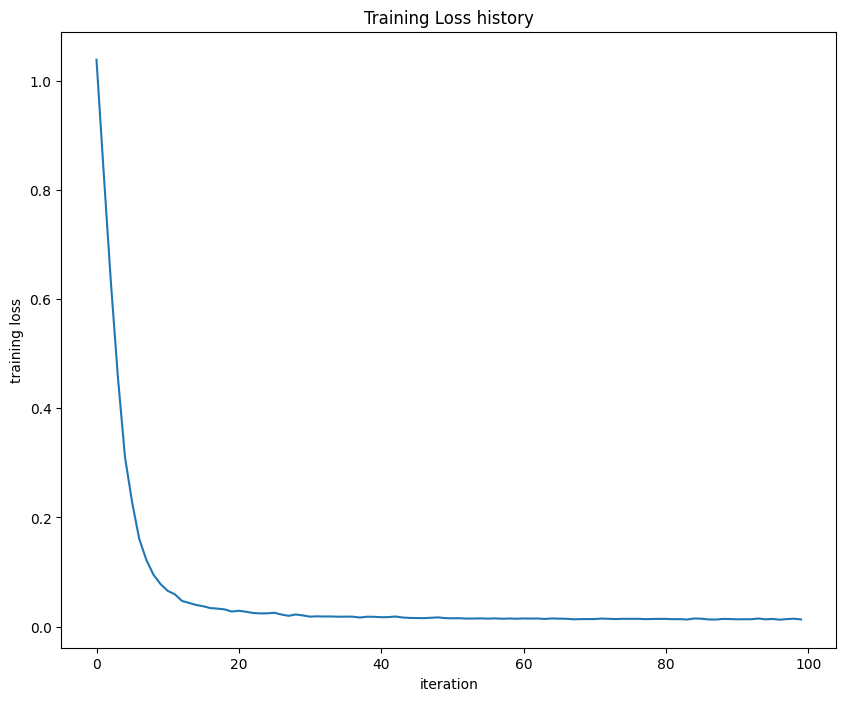

In [8]:
from nn_classification_utils.solver import Solver

data = {'X_train': X, 'y_train': y, 'X_val': None, 'y_val': None}

model = TwoLayerNet(input_size, hidden_size, num_classes, weight_scale=1e-1, reg=5e-6)
solver = Solver(model, data, optim_config={'learning_rate': 1e-1,},lr_decay=0.95, num_epochs =
                    100, batch_size = 200, verbose = False)
solver.train()

print('Final training loss: ', solver.loss_history[-1])

# plot the loss history
plt.plot(solver.loss_history)
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Load the data
Now that you have implemented a two-layer network that passes gradient checks and works on toy data, it's time to load up our favorite CIFAR-10 data so we can use it to train a classifier on a real dataset.

In [9]:
from data_utils import load_CIFAR10

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the two-layer neural net classifier. These are the same steps as
    we used for the SVM, but condensed to a single function.
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'datasets/cifar-10-batches-py'
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis=0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image

    # Reshape data to rows
    X_train = X_train.reshape(num_training, -1)
    X_val = X_val.reshape(num_validation, -1)
    X_test = X_test.reshape(num_test, -1)

    return X_train, y_train, X_val, y_val, X_test, y_test


# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)


# Train a network
To train our network we will use SGD with momentum. In addition, we will adjust the learning rate with an exponential learning rate schedule as optimization proceeds; after each epoch, we will reduce the learning rate by multiplying it by a decay rate.

In [10]:
from nn_classification_utils.solver import Solver

input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10

data = {'X_train': X_train, 'y_train': y_train, 'X_val': X_val, 'y_val': y_val}

model = TwoLayerNet(input_size, hidden_size, num_classes, reg=0.25, weight_scale=1e-4)

# Train the network
solver = Solver(model, data, optim_config={'learning_rate': 1e-4,},lr_decay=0.95, num_epochs =
                    5, batch_size = 200, verbose = True)
solver.train()

# Predict on the validation set
val_acc = solver.check_accuracy(X_val, y_val)
print('Validation accuracy: ', val_acc)

(Iteration 1 / 1225) loss: 2.302990
(Epoch 0 / 5) train acc: 0.098000; val_acc: 0.081000
(Iteration 101 / 1225) loss: 2.302629
(Iteration 201 / 1225) loss: 2.297792
(Epoch 1 / 5) train acc: 0.191000; val_acc: 0.174000
(Iteration 301 / 1225) loss: 2.257553
(Iteration 401 / 1225) loss: 2.179915
(Epoch 2 / 5) train acc: 0.202000; val_acc: 0.217000
(Iteration 501 / 1225) loss: 2.155008
(Iteration 601 / 1225) loss: 2.068288
(Iteration 701 / 1225) loss: 1.966334
(Epoch 3 / 5) train acc: 0.254000; val_acc: 0.255000
(Iteration 801 / 1225) loss: 2.050891
(Iteration 901 / 1225) loss: 2.042734
(Epoch 4 / 5) train acc: 0.276000; val_acc: 0.286000
(Iteration 1001 / 1225) loss: 1.928477
(Iteration 1101 / 1225) loss: 1.884274
(Iteration 1201 / 1225) loss: 1.951619
(Epoch 5 / 5) train acc: 0.308000; val_acc: 0.300000
Validation accuracy:  0.3


# Debug the training
With the default parameters we provided above, you should get a validation accuracy of about 0.30 on the validation set. This isn't very good.

One strategy for getting insight into what's wrong is to plot the loss function and the accuracies on the training and validation sets during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network. In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

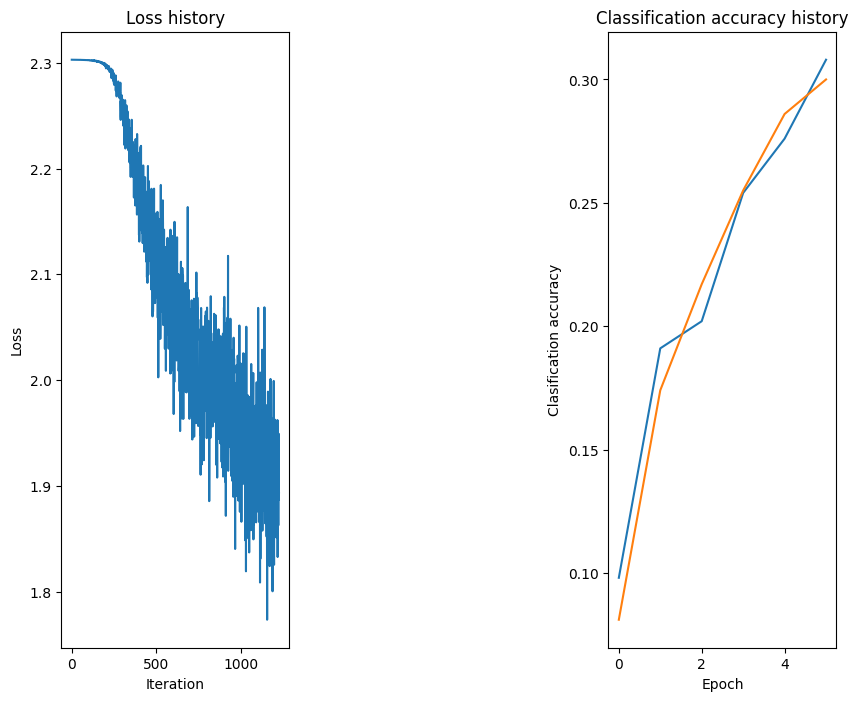

In [11]:
# Plot the loss function and train / validation accuracies
plt.subplot(1, 3, 1)
plt.plot(solver.loss_history)
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(1, 3, 3)
plt.plot(solver.train_acc_history, label='train')
plt.plot(solver.val_acc_history, label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Clasification accuracy')
plt.show()

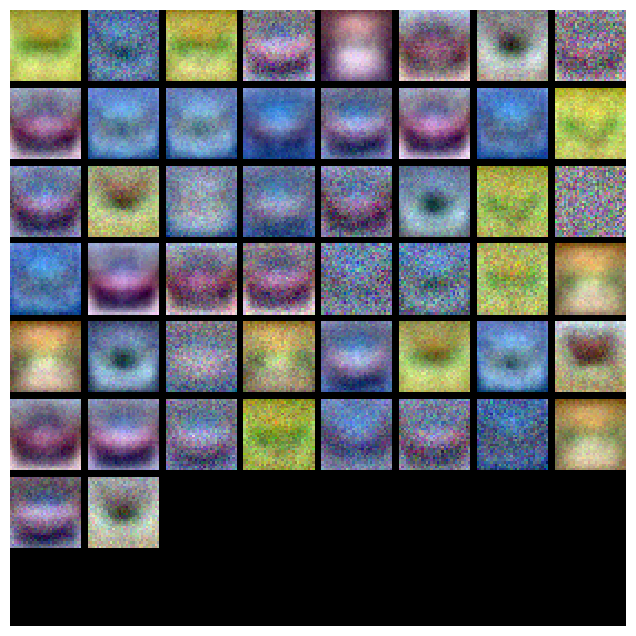

In [12]:
from vis_utils import visualize_grid

# Visualize the weights of the network

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(model)

# Tune your hyperparameters

**What's wrong?**. Looking at the visualizations above, we see that the loss is decreasing more or less linearly, which seems to suggest that the learning rate may be too low. Moreover, there is no gap between the training and validation accuracy, suggesting that the model we used has low capacity, and that we should increase its size. On the other hand, with a very large model we would expect to see more overfitting, which would manifest itself as a very large gap between the training and validation accuracy.

**Tuning**. Tuning the hyperparameters and developing intuition for how they affect the final performance is a large part of using Neural Networks, so we want you to get a lot of practice. Below, you should experiment with different values of the various hyperparameters, including hidden layer size, learning rate, numer of training epochs, and regularization strength. You might also consider tuning the learning rate decay, but you should be able to get good performance using the default value.

**Approximate results**. You should be aim to achieve a classification accuracy of greater than 48% on the validation set. Our best network gets over 52% on the validation set.

**Experiment**: You goal in this exercise is to get as good of a result on CIFAR-10 as you can, with a fully-connected Neural Network. We recommend estabilishing a design that ensures a result of over 52%. Feel free implement your own techniques.

In [ ]:
best_net = None # store the best model into this
best_val_acc = -1

In [ ]:
hidden_unit = 300
lr = 5e-4
reg_weight = 0.25
optim_type = 'sgd'
num_epochs = 20

#################################################################################
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_net.                                                            #
#                                                                               #
# To help debug your network, it may help to use visualizations similar to the  #
# ones we used above; these visualizations will have significant qualitative    #
# differences from the ones we saw above for the poorly tuned network.          #
#                                                                               #
# Tweaking hyperparameters by hand can be fun, but you might find it useful to  #
# write code to sweep through possible combinations of hyperparameters          #
# automatically like we did on the previous exercises.                          #
#################################################################################
neural_net = TwoLayerNet(input_size, hidden_unit, num_classes, weight_scale=1e-4, reg=reg_weight)
solver = Solver(neural_net, data, optim_config={'learning_rate': lr,},lr_decay=0.95,
                update_rule=optim_type, num_epochs = num_epochs, batch_size = 200, verbose = True)
solver.train()
val_acc = solver.val_acc_history[-1]

if (best_val_acc < solver.best_val_acc):
    best_model = model
    best_solver = solver
    best_val_acc = solver.best_val_acc

print(val_acc)
solver = best_solver
print ("Better Validation accuracy is: " + str(best_val_acc))
#################################################################################
#                               END OF YOUR CODE                                #
#################################################################################

(Iteration 1 / 4900) loss: 2.304894
(Epoch 0 / 20) train acc: 0.126000; val_acc: 0.117000
(Iteration 101 / 4900) loss: 2.055513
(Iteration 201 / 4900) loss: 1.941228
(Epoch 1 / 20) train acc: 0.357000; val_acc: 0.351000
(Iteration 301 / 4900) loss: 1.700897
(Iteration 401 / 4900) loss: 1.549331
(Epoch 2 / 20) train acc: 0.410000; val_acc: 0.425000
(Iteration 501 / 4900) loss: 1.698825
(Iteration 601 / 4900) loss: 1.625836
(Iteration 701 / 4900) loss: 1.745052
(Epoch 3 / 20) train acc: 0.439000; val_acc: 0.453000
(Iteration 801 / 4900) loss: 1.494507
(Iteration 901 / 4900) loss: 1.574982
(Epoch 4 / 20) train acc: 0.448000; val_acc: 0.472000
(Iteration 1001 / 4900) loss: 1.489237
(Iteration 1101 / 4900) loss: 1.612789
(Iteration 1201 / 4900) loss: 1.550315
(Epoch 5 / 20) train acc: 0.485000; val_acc: 0.462000
(Iteration 1301 / 4900) loss: 1.640762
(Iteration 1401 / 4900) loss: 1.505352
(Epoch 6 / 20) train acc: 0.495000; val_acc: 0.478000
(Iteration 1501 / 4900) loss: 1.519492
(Iteration

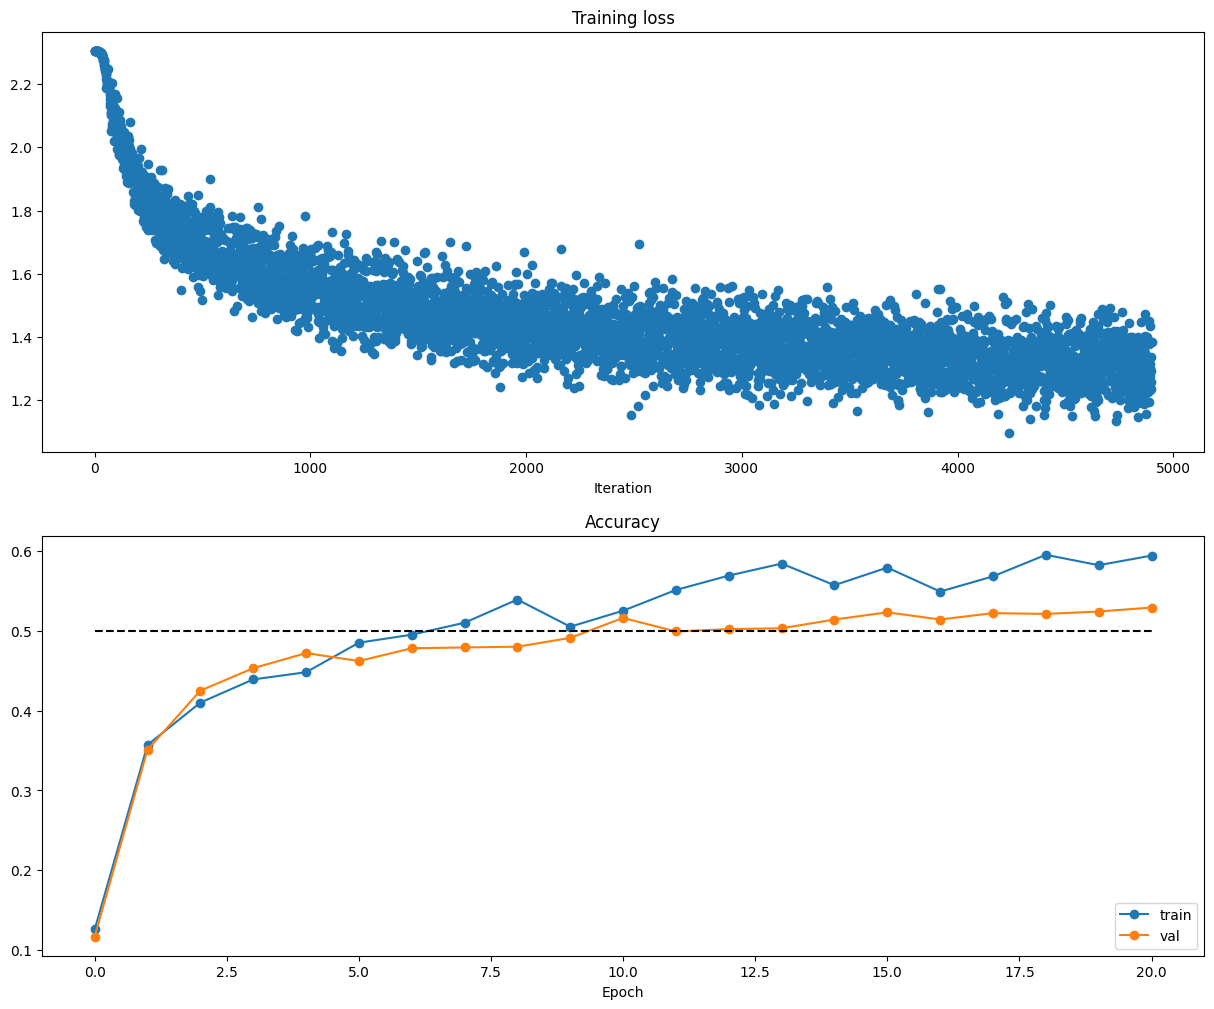

In [ ]:
# Run this cell to visualize training loss and train / val accuracy

plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(best_solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(best_solver.train_acc_history, '-o', label='train')
plt.plot(best_solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(best_solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()

#from the below plots it's evident that this is overfitting, we can better accuracy by increasing regularization.

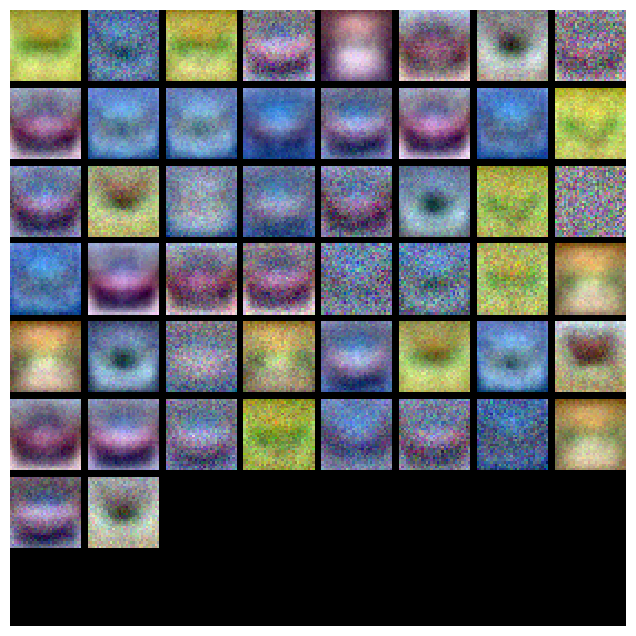

In [ ]:
# visualize the weights of the best network
show_net_weights(best_model)

# Run on the test set

In [ ]:
test_acc = best_solver.check_accuracy(X_test, y_test)
print('Test accuracy: ', test_acc)

Test accuracy:  0.536
